# Machine Failure Classification from Sensor Data

This notebook explores clustering and semi-supervised approaches for assigning failure labels to machine breakdowns based on 20 sensor measurements.
The dataset contains 40 expert-labeled failures and 1560 unlabeled failures.

## 1. Data Overview and Preparation

In this section, I load the dataset, inspect its structure, and separate the labeled and unlabeled machine failures.
I also prepare the sensor feature matrix for downstream clustering and classification experiments.

In [170]:
import pandas as pd
import numpy as np

In [171]:
df = pd.read_csv("../data/data_sensors.csv")

In [172]:
df.head()

,Sensor 0,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Label
0,-0.545785,-0.639964,0.323172,0.870056,0.589634,-0.654516,0.758626,-0.944226,-0.361981,-0.738958,...,0.367026,-0.684776,-0.442127,-0.797051,-0.849937,0.109651,0.275428,0.724551,-0.957438,NaN
1,0.291232,-0.188508,-0.266294,-0.931173,0.990036,-0.782436,-0.356253,0.777890,0.864639,0.510940,...,-0.144257,-0.403463,-0.029867,-0.876624,0.976521,0.983823,-0.095941,0.987311,0.245192,NaN
2,0.680580,0.423410,0.734204,-0.023014,0.639396,-0.495548,-0.373933,-0.842535,-0.228202,-0.330048,...,-0.675210,0.634603,-0.317718,-0.362630,-0.658235,0.290307,-0.560638,-0.477552,-0.206955,NaN
3,0.055538,0.116893,0.421156,0.154056,-0.107440,-0.618401,-0.915526,0.967082,-0.205136,0.591844,...,-0.373325,-0.306537,0.161707,-0.757658,-0.838197,-0.658364,0.210658,0.204989,0.663093,NaN
4,0.521701,0.066350,0.285818,0.083620,0.166119,0.387446,0.205991,-0.266857,-0.288621,0.542669,...,-0.176694,0.727822,0.274874,-0.412379,-0.657580,0.726756,0.283499,0.579462,-0.524631,NaN


In [173]:
df.shape

(1600, 21)

In [174]:
df.columns

Index(['Sensor 0', 'Sensor 1', 'Sensor 2', 'Sensor 3', 'Sensor 4', 'Sensor 5',
       'Sensor 6', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 10',
       'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15',
       'Sensor 16', 'Sensor 17', 'Sensor 18', 'Sensor 19', 'Label'],
      dtype='str')

In [175]:
df["Label"].count(), df["Label"].isna().sum()

(np.int64(40), np.int64(1560))

In [176]:
df["Label"].value_counts(dropna=False)

Label
NaN    1560
3.0      20
2.0      10
1.0      10
Name: count, dtype: int64

In [177]:
labeled_df = df[df["Label"].notna()]
unlabeled_df = df[df["Label"].isna()]

labeled_df.shape, unlabeled_df.shape

((40, 21), (1560, 21))

In [178]:
sensor_columns = [col for col in df.columns if col.startswith("Sensor")]

X = df[sensor_columns]
y = df["Label"]

X.shape, y.shape

((1600, 20), (1600,))

In [179]:
X.isna().sum()

Sensor 0     0
Sensor 1     0
Sensor 2     0
Sensor 3     0
Sensor 4     0
Sensor 5     0
Sensor 6     0
Sensor 7     0
Sensor 8     0
Sensor 9     0
Sensor 10    0
Sensor 11    0
Sensor 12    0
Sensor 13    0
Sensor 14    0
Sensor 15    0
Sensor 16    0
Sensor 17    0
Sensor 18    0
Sensor 19    0
dtype: int64

In [180]:
X.describe()

,Sensor 0,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,Sensor 10,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19
count,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000
mean,-0.003901,0.010692,0.003611,0.016913,0.006504,-0.035332,0.002607,-0.023096,0.014207,0.001201,-0.008101,-0.000107,0.006054,-0.003777,0.003583,0.009220,0.026797,0.018740,0.018144,0.010668
std,0.578326,0.580784,0.359632,0.583571,0.570841,0.593607,0.572523,0.588614,0.579928,0.602691,0.577587,0.584802,0.577892,0.359788,0.584293,0.582116,0.569598,0.578555,0.583309,0.576219
min,-0.998098,-0.992518,-0.800000,-0.999775,-0.999870,-0.999669,-0.996949,-0.998761,-0.998044,-0.999523,-0.998975,-0.999330,-0.996221,-0.800000,-0.998908,-0.998526,-0.999408,-0.998213,-0.999880,-0.998559
25%,-0.507756,-0.488596,-0.259969,-0.504151,-0.485490,-0.576116,-0.493367,-0.531029,-0.473253,-0.559439,-0.504933,-0.514553,-0.524190,-0.265276,-0.510638,-0.488482,-0.457106,-0.505591,-0.478406,-0.470953
50%,0.004809,0.017735,0.000516,0.051528,0.000811,-0.051875,0.015700,-0.043717,0.004869,0.034202,-0.024177,0.009776,0.024858,-0.005893,0.031814,0.006501,0.038331,0.009060,0.032383,0.020862
75%,0.476584,0.513715,0.270990,0.512762,0.495880,0.481036,0.484419,0.490271,0.503751,0.547635,0.501495,0.516638,0.503594,0.259134,0.522166,0.530700,0.513615,0.537619,0.543224,0.510085
max,0.999610,0.999463,0.800000,0.999733,0.992920,0.996972,0.999369,0.999376,0.999143,0.999618,0.999918,0.995784,0.998642,0.800000,0.998700,0.997060,0.995780,0.999772,0.999192,0.999967


## 2. Exploratory Visualization with PCA

To get an initial sense of the structure of the data, I project the 20-dimensional sensor space into 2 dimensions using PCA.
This helps assess whether the known failure classes appear naturally separable in the raw feature space.

In [181]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [182]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [183]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Label"] = y
pca_df.head()

,PC1,PC2,Label
0,-0.824192,-0.467667,NaN
1,0.621474,2.770419,NaN
2,0.931716,-0.157073,NaN
3,0.004815,-0.622132,NaN
4,-0.207360,0.566636,NaN


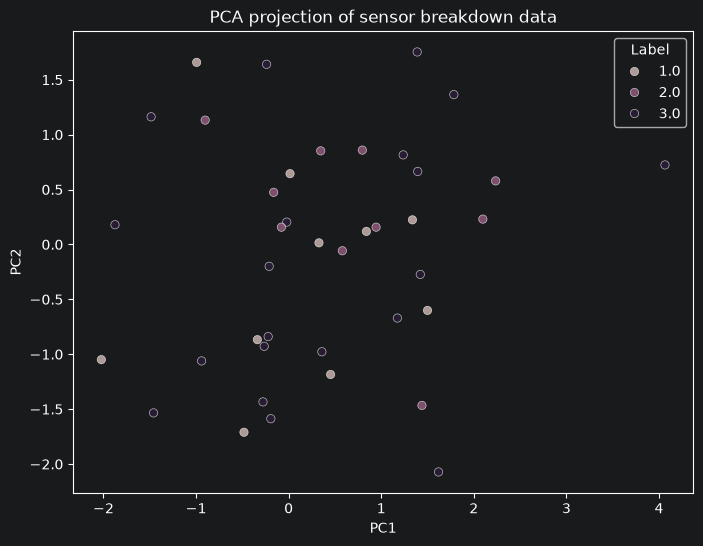

In [184]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Label", alpha=0.7)
plt.title("PCA projection of sensor breakdown data")
plt.show()

## 3. Unsupervised Clustering Baselines

I first test whether the machine failures can be grouped without using any label information.
To do this, I evaluate several unsupervised clustering methods on the sensor data and compare how well they align with the known failure labels.

### 3.1 KMeans Clustering

In [185]:
from sklearn.cluster import KMeans

In [186]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [187]:
results_df = df.copy()
results_df["Cluster"] = clusters

results_df.head()

,Sensor 0,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Label,Cluster
0,-0.545785,-0.639964,0.323172,0.870056,0.589634,-0.654516,0.758626,-0.944226,-0.361981,-0.738958,...,-0.684776,-0.442127,-0.797051,-0.849937,0.109651,0.275428,0.724551,-0.957438,NaN,0
1,0.291232,-0.188508,-0.266294,-0.931173,0.990036,-0.782436,-0.356253,0.777890,0.864639,0.510940,...,-0.403463,-0.029867,-0.876624,0.976521,0.983823,-0.095941,0.987311,0.245192,NaN,2
2,0.680580,0.423410,0.734204,-0.023014,0.639396,-0.495548,-0.373933,-0.842535,-0.228202,-0.330048,...,0.634603,-0.317718,-0.362630,-0.658235,0.290307,-0.560638,-0.477552,-0.206955,NaN,1
3,0.055538,0.116893,0.421156,0.154056,-0.107440,-0.618401,-0.915526,0.967082,-0.205136,0.591844,...,-0.306537,0.161707,-0.757658,-0.838197,-0.658364,0.210658,0.204989,0.663093,NaN,2
4,0.521701,0.066350,0.285818,0.083620,0.166119,0.387446,0.205991,-0.266857,-0.288621,0.542669,...,0.727822,0.274874,-0.412379,-0.657580,0.726756,0.283499,0.579462,-0.524631,NaN,1


In [188]:
results_df["Cluster"].value_counts().sort_index()

Cluster
0    553
1    495
2    552
Name: count, dtype: int64

In [189]:
results_df[results_df["Label"].notna()].groupby(["Cluster", "Label"]).size().unstack(fill_value=0)

Label,1.0,2.0,3.0
Cluster,,,
0,4,0,6
1,3,7,7
2,3,3,7


In [190]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_scaled, clusters)
silhouette

0.0352048574907303

In [191]:
kmeans_4 = KMeans(n_clusters=4, random_state=42)
clusters_4 = kmeans_4.fit_predict(X_scaled)
silhouette_score(X_scaled, clusters_4)

0.03400128401706757

In [192]:
kmeans_5 = KMeans(n_clusters=5, random_state=42)
clusters_5 = kmeans_5.fit_predict(X_scaled)
silhouette_score(X_scaled, clusters_5)

0.03494992709506886

### 3.2 Agglomerative Clustering

In [193]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k)
    agg_clusters = agg.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, agg_clusters)

    agg_results_df = df.copy()
    agg_results_df["Cluster"] = agg_clusters

    print(f"\nAgglomerative Clustering | k={k}")
    print(f"Silhouette score: {score:.4f}")
    print("\nCluster sizes:")
    print(agg_results_df["Cluster"].value_counts().sort_index())

    print("\nKnown labels per cluster:")
    display(
        agg_results_df[agg_results_df["Label"].notna()]
        .groupby(["Cluster", "Label"])
        .size()
        .unstack(fill_value=0)
    )


Agglomerative Clustering | k=3
Silhouette score: 0.0119

Cluster sizes:
Cluster
0    690
1    310
2    600
Name: count, dtype: int64

Known labels per cluster:


Label,1.0,2.0,3.0
Cluster,,,
0,3,4,9
1,4,4,3
2,3,2,8



Agglomerative Clustering | k=4
Silhouette score: 0.0080

Cluster sizes:
Cluster
0    600
1    274
2    416
3    310
Name: count, dtype: int64

Known labels per cluster:


Label,1.0,2.0,3.0
Cluster,,,
0,3,2,8
1,3,1,3
2,0,3,6
3,4,4,3



Agglomerative Clustering | k=5
Silhouette score: 0.0073

Cluster sizes:
Cluster
0    416
1    298
2    302
3    310
4    274
Name: count, dtype: int64

Known labels per cluster:


Label,1.0,2.0,3.0
Cluster,,,
0,0,3,6
1,0,2,4
2,3,0,4
3,4,4,3
4,3,1,3


In [194]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    agg = AgglomerativeClustering(n_clusters=k)
    agg_clusters = agg.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, agg_clusters)

    agg_results_df = df.copy()
    agg_results_df["Cluster"] = agg_clusters

    print("=" * 60)
    print(f"Agglomerative Clustering | k={k}")
    print(f"Silhouette score: {score:.4f}\n")

    print("Cluster sizes:")
    print(agg_results_df["Cluster"].value_counts().sort_index().to_string())
    print()

    print("Known labels per cluster:")
    label_table = (
        agg_results_df[agg_results_df["Label"].notna()]
        .groupby(["Cluster", "Label"])
        .size()
        .unstack(fill_value=0)
    )
    print(label_table.to_string())
    print()

Agglomerative Clustering | k=3
Silhouette score: 0.0119

Cluster sizes:
Cluster
0    690
1    310
2    600

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          3    4    9
1          4    4    3
2          3    2    8

Agglomerative Clustering | k=4
Silhouette score: 0.0080

Cluster sizes:
Cluster
0    600
1    274
2    416
3    310

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          3    2    8
1          3    1    3
2          0    3    6
3          4    4    3

Agglomerative Clustering | k=5
Silhouette score: 0.0073

Cluster sizes:
Cluster
0    416
1    298
2    302
3    310
4    274

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          0    3    6
1          0    2    4
2          3    0    4
3          4    4    3
4          3    1    3



### 3.3 Gaussian Mixture Model

In [195]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm_clusters = gmm.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, gmm_clusters)

    gmm_results_df = df.copy()
    gmm_results_df["Cluster"] = gmm_clusters

    print("=" * 60)
    print(f"Gaussian Mixture | k={k}")
    print(f"Silhouette score: {score:.4f}\n")

    print("Cluster sizes:")
    print(gmm_results_df["Cluster"].value_counts().sort_index().to_string())
    print()

    print("Known labels per cluster:")
    label_table = (
        gmm_results_df[gmm_results_df["Label"].notna()]
        .groupby(["Cluster", "Label"])
        .size()
        .unstack(fill_value=0)
    )
    print(label_table.to_string())
    print()

Gaussian Mixture | k=3
Silhouette score: 0.0276

Cluster sizes:
Cluster
0    624
1    524
2    452

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          5    0    8
1          3    7    7
2          2    3    5

Gaussian Mixture | k=4
Silhouette score: 0.0234

Cluster sizes:
Cluster
0    372
1    445
2    275
3    508

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          1    4    8
1          4    0    3
2          0    1    4
3          5    5    5

Gaussian Mixture | k=5
Silhouette score: 0.0086

Cluster sizes:
Cluster
0    181
1    310
2    354
3    590
4    165

Known labels per cluster:
Label    1.0  2.0  3.0
Cluster               
0          1    0    5
1          2    2    3
2          1    2    5
3          6    6    4
4          0    0    3



### Takeaway

Pure unsupervised clustering on the raw 20-sensor space did not cleanly separate the known machine failure classes.
This suggests that either the raw feature space is noisy, the failure classes overlap, or additional label information is needed to guide the grouping.

## 4. Label-Guided and Semi-Supervised Approaches

Since pure clustering does not cleanly separate the known failure classes, I next use the 40 labeled failures to guide the classification of the unlabeled ones.
I also reduce the feature space to the most discriminative sensors before evaluating the downstream models.

### 4.1 k-Nearest Neighbors

In [196]:
labeled_mask = y.notna()

X_labeled = X_scaled[labeled_mask]
X_unlabeled = X_scaled[~labeled_mask]
y_labeled = y[labeled_mask]

X_labeled.shape, X_unlabeled.shape, y_labeled.shape

((40, 20), (1560, 20), (40,))

In [197]:
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_labeled)

distances, neighbor_indices = knn.kneighbors(X_unlabeled)

distances.shape, neighbor_indices.shape

((1560, 5), (1560, 5))

In [198]:
y_labeled_array = y_labeled.to_numpy()

neighbor_labels = y_labeled_array[neighbor_indices]

neighbor_labels[:5]

array([[3., 3., 3., 3., 2.],
       [1., 3., 3., 1., 3.],
       [2., 2., 1., 2., 1.],
       [1., 3., 1., 2., 2.],
       [1., 1., 3., 1., 3.]])

In [199]:
print("neighbor_labels shape:", neighbor_labels.shape)
print(neighbor_labels[:10])

neighbor_labels shape: (1560, 5)
[[3. 3. 3. 3. 2.]
 [1. 3. 3. 1. 3.]
 [2. 2. 1. 2. 1.]
 [1. 3. 1. 2. 2.]
 [1. 1. 3. 1. 3.]
 [3. 1. 1. 3. 2.]
 [3. 2. 2. 2. 3.]
 [2. 1. 2. 1. 1.]
 [3. 1. 1. 1. 2.]
 [2. 2. 1. 3. 3.]]


In [200]:
from scipy.stats import mode

predicted_labels = mode(neighbor_labels, axis=1, keepdims=False).mode
confidence = np.array([
    np.mean(row == pred)
    for row, pred in zip(neighbor_labels, predicted_labels)
])

predicted_labels[:10], confidence[:10]

(array([3., 3., 2., 1., 1., 1., 2., 1., 1., 2.]),
 array([0.8, 0.6, 0.6, 0.4, 0.6, 0.4, 0.6, 0.6, 0.6, 0.4]))

In [201]:
unlabeled_results = df[~labeled_mask].copy()
unlabeled_results["Predicted_Label"] = predicted_labels
unlabeled_results["Confidence"] = confidence

unlabeled_results[["Predicted_Label", "Confidence"]].head(10)

,Predicted_Label,Confidence
0,3.0,0.8
1,3.0,0.6
2,2.0,0.6
3,1.0,0.4
4,1.0,0.6
5,1.0,0.4
7,2.0,0.6
8,1.0,0.6
9,1.0,0.6
10,2.0,0.4


In [202]:
print(unlabeled_results["Predicted_Label"].value_counts().sort_index().to_string())
print(unlabeled_results["Confidence"].value_counts().sort_index().to_string())
high_confidence_results = unlabeled_results[unlabeled_results["Confidence"] >= 0.8]

print("High-confidence predictions:", len(high_confidence_results))
print()
print(high_confidence_results["Predicted_Label"].value_counts().sort_index().to_string())

Predicted_Label
1.0    812
2.0    339
3.0    409
Confidence
0.4    573
0.6    768
0.8    202
1.0     17
High-confidence predictions: 219

Predicted_Label
1.0    107
2.0     24
3.0     88


In [203]:
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode
from sklearn.metrics import classification_report, confusion_matrix

knn_labeled = NearestNeighbors(n_neighbors=6)
knn_labeled.fit(X_labeled)

dist_labeled, idx_labeled = knn_labeled.kneighbors(X_labeled)

neighbor_indices_labeled = idx_labeled[:, 1:]
neighbor_labels_labeled = y_labeled.to_numpy()[neighbor_indices_labeled]

predicted_labeled = mode(neighbor_labels_labeled, axis=1, keepdims=False).mode

print("Confusion matrix:")
print(confusion_matrix(y_labeled, predicted_labeled))

print("\nClassification report:")
print(classification_report(y_labeled, predicted_labeled))

Confusion matrix:
[[ 6  2  2]
 [ 8  0  2]
 [11  6  3]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.24      0.60      0.34        10
         2.0       0.00      0.00      0.00        10
         3.0       0.43      0.15      0.22        20

    accuracy                           0.23        40
   macro avg       0.22      0.25      0.19        40
weighted avg       0.27      0.23      0.20        40



### 4.2 Centroid-Based Classification

In [204]:
labeled_df = df[df["Label"].notna()].copy()

sensor_means_by_label = labeled_df.groupby("Label")[sensor_columns].mean()
print(sensor_means_by_label.to_string())

       Sensor 0  Sensor 1  Sensor 2  Sensor 3  Sensor 4  Sensor 5  Sensor 6  Sensor 7  Sensor 8  Sensor 9  Sensor 10  Sensor 11  Sensor 12  Sensor 13  Sensor 14  Sensor 15  Sensor 16  Sensor 17  Sensor 18  Sensor 19
Label                                                                                                                                                                                                                  
1.0   -0.249092  0.002101 -0.038602  0.144437 -0.058916  0.180730 -0.174589  0.254549 -0.410670  0.436491  -0.131503  -0.070803   0.040909  -0.041721   0.249780   0.076003   0.177182  -0.064408   0.355734   0.022196
2.0    0.345458  0.219727  0.092048  0.068283 -0.048797  0.040887 -0.169757  0.114741  0.100762 -0.433501   0.033584  -0.141780  -0.119478  -0.038881   0.131611   0.150801  -0.041003  -0.170625  -0.112046  -0.142094
3.0   -0.035101  0.011035 -0.250014 -0.070067 -0.096126 -0.113625 -0.018484 -0.024661  0.130355 -0.042508  -0.114226  -0.170060  -0.1143

In [205]:
label_centroids = labeled_df.groupby("Label")[sensor_columns].mean()
print(label_centroids.to_string())

       Sensor 0  Sensor 1  Sensor 2  Sensor 3  Sensor 4  Sensor 5  Sensor 6  Sensor 7  Sensor 8  Sensor 9  Sensor 10  Sensor 11  Sensor 12  Sensor 13  Sensor 14  Sensor 15  Sensor 16  Sensor 17  Sensor 18  Sensor 19
Label                                                                                                                                                                                                                  
1.0   -0.249092  0.002101 -0.038602  0.144437 -0.058916  0.180730 -0.174589  0.254549 -0.410670  0.436491  -0.131503  -0.070803   0.040909  -0.041721   0.249780   0.076003   0.177182  -0.064408   0.355734   0.022196
2.0    0.345458  0.219727  0.092048  0.068283 -0.048797  0.040887 -0.169757  0.114741  0.100762 -0.433501   0.033584  -0.141780  -0.119478  -0.038881   0.131611   0.150801  -0.041003  -0.170625  -0.112046  -0.142094
3.0   -0.035101  0.011035 -0.250014 -0.070067 -0.096126 -0.113625 -0.018484 -0.024661  0.130355 -0.042508  -0.114226  -0.170060  -0.1143

In [206]:
from scipy.spatial.distance import cdist

centroid_distances = cdist(X_unlabeled, label_centroids.values, metric="euclidean")
centroid_distances.shape

(1560, 3)

In [207]:
closest_centroid_idx = np.argmin(centroid_distances, axis=1)

centroid_predicted_labels = label_centroids.index.to_numpy()[closest_centroid_idx]

centroid_predicted_labels[:10]

array([3., 3., 2., 1., 1., 2., 2., 2., 1., 2.])

In [208]:
sorted_distances = np.sort(centroid_distances, axis=1)

nearest_dist = sorted_distances[:, 0]
second_nearest_dist = sorted_distances[:, 1]

centroid_margin = second_nearest_dist - nearest_dist

centroid_margin[:10]

array([0.23999619, 0.16421525, 0.20499706, 0.11969349, 0.2005106 ,
       0.01440103, 0.10807001, 0.14126267, 0.09455235, 0.14282953])

In [209]:
centroid_results = df[~labeled_mask].copy()
centroid_results["Predicted_Label"] = centroid_predicted_labels
centroid_results["Margin"] = centroid_margin

centroid_results[["Predicted_Label", "Margin"]].head(10)

,Predicted_Label,Margin
0,3.0,0.239996
1,3.0,0.164215
2,2.0,0.204997
3,1.0,0.119693
4,1.0,0.200511
5,2.0,0.014401
7,2.0,0.108070
8,2.0,0.141263
9,1.0,0.094552
10,2.0,0.142830


In [210]:
print(centroid_results["Predicted_Label"].value_counts().sort_index().to_string())
print(centroid_results["Margin"].describe().to_string())
centroid_high_conf = centroid_results[centroid_results["Margin"] >= 0.15]

print("High-confidence predictions:", len(centroid_high_conf))
print()
print(centroid_high_conf["Predicted_Label"].value_counts().sort_index().to_string())

Predicted_Label
1.0    490
2.0    544
3.0    526
count    1560.000000
mean        0.134853
std         0.109384
min         0.000022
25%         0.047553
50%         0.109488
75%         0.193365
max         0.643759
High-confidence predictions: 576

Predicted_Label
1.0    225
2.0    205
3.0    146


In [211]:
from sklearn.metrics import classification_report, confusion_matrix
from scipy.spatial.distance import cdist

# Leave-one-out evaluation for centroid-based classification
# For each labeled sample:
# 1. remove it from the labeled set
# 2. compute class centroids from the remaining labeled samples
# 3. assign the sample to the nearest centroid

y_labeled_series = labeled_df["Label"]
loo_centroid_preds = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_df = labeled_df.drop(labeled_df.index[i])
    test_row = labeled_df.iloc[[i]][sensor_columns]

    # Compute centroids from the remaining labeled examples
    train_centroids = train_df.groupby("Label")[sensor_columns].mean()

    # Compute distances from the held-out sample to each centroid
    dists = cdist(test_row, train_centroids.values, metric="euclidean")

    # Predict the label of the nearest centroid
    pred_label = train_centroids.index[np.argmin(dists)]
    loo_centroid_preds.append(pred_label)

loo_centroid_preds = np.array(loo_centroid_preds)

print("Confusion matrix:")
print(confusion_matrix(y_labeled_series, loo_centroid_preds))

print("\nClassification report:")
print(classification_report(y_labeled_series, loo_centroid_preds))

Confusion matrix:
[[4 2 4]
 [1 2 7]
 [4 9 7]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.44      0.40      0.42        10
         2.0       0.15      0.20      0.17        10
         3.0       0.39      0.35      0.37        20

    accuracy                           0.33        40
   macro avg       0.33      0.32      0.32        40
weighted avg       0.34      0.33      0.33        40



In [212]:
output_columns = sensor_columns + ["Predicted_Label", "Margin"]

centroid_results[output_columns].to_csv(
    "../outputs/centroid_label_assignments.csv",
    index=False
)

#### 4.2.1 Feature Selection: Most Discriminative Sensors

Since the initial clustering and label-guided baselines were weak, I tested whether focusing only on the sensors that differ most across the known labels improves the downstream classification approaches.

In [213]:
# Rank sensors by the difference between their highest and lowest mean value across labels
sensor_discriminative_score = (
    sensor_means_by_label.max(axis=0) - sensor_means_by_label.min(axis=0)
)

sensor_ranking = sensor_discriminative_score.sort_values(ascending=False)

print(sensor_ranking.to_string())

Sensor 9     0.869992
Sensor 0     0.594550
Sensor 8     0.541025
Sensor 18    0.467780
Sensor 2     0.342061
Sensor 5     0.294356
Sensor 14    0.292811
Sensor 7     0.279210
Sensor 16    0.218185
Sensor 1     0.217626
Sensor 3     0.214504
Sensor 15    0.190681
Sensor 10    0.165086
Sensor 19    0.164289
Sensor 12    0.160386
Sensor 6     0.156105
Sensor 13    0.130636
Sensor 17    0.106217
Sensor 11    0.099257
Sensor 4     0.047329


#### 4.2.2 Centroid Classification Using the Top 5 Discriminative Sensors

To reduce noise from less informative sensors, I repeated the centroid-based classification using only the top 5 sensors with the largest mean differences across the known labels.

In [214]:
top_5_sensors = sensor_ranking.head(5).index.tolist()
print(top_5_sensors)

['Sensor 9', 'Sensor 0', 'Sensor 8', 'Sensor 18', 'Sensor 2']


In [215]:
from sklearn.metrics import classification_report, confusion_matrix
from scipy.spatial.distance import cdist

loo_top5_preds = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_df = labeled_df.drop(labeled_df.index[i])
    test_row = labeled_df.iloc[[i]][top_5_sensors]

    # Compute class centroids using only the selected sensors
    train_centroids = train_df.groupby("Label")[top_5_sensors].mean()

    # Compute distances from the held-out sample to each centroid
    dists = cdist(test_row, train_centroids.values, metric="euclidean")

    # Predict the label of the nearest centroid
    pred_label = train_centroids.index[np.argmin(dists)]
    loo_top5_preds.append(pred_label)

loo_top5_preds = np.array(loo_top5_preds)

print("Confusion matrix:")
print(confusion_matrix(labeled_df["Label"], loo_top5_preds))

print("\nClassification report:")
print(classification_report(labeled_df["Label"], loo_top5_preds))

Confusion matrix:
[[7 0 3]
 [1 6 3]
 [5 6 9]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.54      0.70      0.61        10
         2.0       0.50      0.60      0.55        10
         3.0       0.60      0.45      0.51        20

    accuracy                           0.55        40
   macro avg       0.55      0.58      0.56        40
weighted avg       0.56      0.55      0.55        40



In [216]:
from scipy.spatial.distance import cdist

# Compute label centroids using only the top 5 discriminative sensors
top5_centroids = labeled_df.groupby("Label")[top_5_sensors].mean()

# Compute distances from each unlabeled breakdown to each label centroid
top5_distances = cdist(
    df.loc[~labeled_mask, top_5_sensors],
    top5_centroids.values,
    metric="euclidean"
)

# Assign each unlabeled breakdown to the nearest centroid
top5_closest_idx = np.argmin(top5_distances, axis=1)
top5_predicted_labels = top5_centroids.index.to_numpy()[top5_closest_idx]

# Confidence margin = distance to second-closest centroid minus distance to closest centroid
sorted_top5_distances = np.sort(top5_distances, axis=1)
top5_margin = sorted_top5_distances[:, 1] - sorted_top5_distances[:, 0]

# Build results table
top5_results = df.loc[~labeled_mask].copy()
top5_results["Predicted_Label"] = top5_predicted_labels
top5_results["Margin"] = top5_margin

top5_results[["Predicted_Label", "Margin"]].head(10)

,Predicted_Label,Margin
0,3.0,0.010202
1,3.0,0.219194
2,2.0,0.539963
3,1.0,0.365642
4,1.0,0.280831
5,3.0,0.279748
7,2.0,0.389844
8,2.0,0.082652
9,3.0,0.137384
10,2.0,0.203874


In [217]:
print(top5_results["Predicted_Label"].value_counts().sort_index().to_string())
print(top5_results["Margin"].describe().to_string())
top5_high_conf = top5_results[top5_results["Margin"] >= 0.15]

print("High-confidence predictions:", len(top5_high_conf))
print()
print(top5_high_conf["Predicted_Label"].value_counts().sort_index().to_string())

Predicted_Label
1.0    458
2.0    557
3.0    545
count    1560.000000
mean        0.213636
std         0.168238
min         0.000201
25%         0.076407
50%         0.173858
75%         0.314332
max         0.796257
High-confidence predictions: 868

Predicted_Label
1.0    297
2.0    338
3.0    233


In [218]:
output_columns = top_5_sensors + ["Predicted_Label", "Margin"]

top5_results[output_columns].to_csv(
    "../outputs/top5_centroid_label_assignments.csv",
    index=False
)

In [219]:
from scipy.spatial.distance import cdist
from sklearn.metrics import accuracy_score

loo_top5_preds = []
loo_top5_margins = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_df = labeled_df.drop(labeled_df.index[i])
    test_row = labeled_df.iloc[[i]][top_5_sensors]

    # Compute class centroids using only the selected sensors
    train_centroids = train_df.groupby("Label")[top_5_sensors].mean()

    # Distances from the held-out sample to each centroid
    dists = cdist(test_row, train_centroids.values, metric="euclidean").flatten()

    # Predicted label = nearest centroid
    pred_label = train_centroids.index[np.argmin(dists)]
    loo_top5_preds.append(pred_label)

    # Margin = second-smallest distance - smallest distance
    sorted_dists = np.sort(dists)
    margin = sorted_dists[1] - sorted_dists[0]
    loo_top5_margins.append(margin)

loo_top5_preds = np.array(loo_top5_preds)
loo_top5_margins = np.array(loo_top5_margins)
y_true = labeled_df["Label"].to_numpy()

# Overall accuracy
print("Overall accuracy:", accuracy_score(y_true, loo_top5_preds))

# High-confidence subsets for several thresholds
for threshold in [0.10, 0.15, 0.20, 0.25]:
    mask = loo_top5_margins >= threshold
    n = mask.sum()
    if n == 0:
        print(f"Threshold {threshold:.2f}: no samples")
    else:
        acc = accuracy_score(y_true[mask], loo_top5_preds[mask])
        print(f"Threshold {threshold:.2f}: {n} samples, accuracy={acc:.3f}")

Overall accuracy: 0.55
Threshold 0.10: 31 samples, accuracy=0.613
Threshold 0.15: 27 samples, accuracy=0.630
Threshold 0.20: 21 samples, accuracy=0.667
Threshold 0.25: 16 samples, accuracy=0.750


### 4.3 Semi-Supervised Learning with Label Spreading

The previous experiments showed that pure clustering on the raw sensor space was weak, and that label-guided centroid classification improved performance when focusing on the most discriminative sensors.

As an additional experiment, I test a **semi-supervised** approach using **Label Spreading**.
This method uses both the 40 labeled failures and the 1560 unlabeled failures. It builds a similarity graph between all samples and propagates labels from labeled points to nearby unlabeled points based on feature similarity.

To evaluate it fairly, I use **leave-one-out validation** on the labeled subset: in each iteration, I hide one labeled example, train Label Spreading using the remaining labels plus all unlabeled data, and check whether the hidden label is recovered correctly.

In [220]:
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_top5 = df[top_5_sensors].to_numpy()
y_full = df["Label"].copy()

labeled_indices = y_full[y_full.notna()].index.to_list()
y_true = y_full.loc[labeled_indices].to_numpy()

loo_ls_preds = []
loo_ls_conf = []

for idx in labeled_indices:
    # Create a semi-supervised label vector:
    # keep all existing labels except the held-out one, which becomes unlabeled (-1)
    y_train = y_full.copy()
    y_train.loc[idx] = np.nan
    y_train = y_train.fillna(-1).to_numpy()

    model = LabelSpreading(kernel="rbf", gamma=20, max_iter=1000)
    model.fit(X_top5, y_train)

    pred_label = model.transduction_[idx]
    loo_ls_preds.append(pred_label)

    # confidence = max predicted probability for the held-out sample
    pred_proba = model.label_distributions_[idx]
    loo_ls_conf.append(pred_proba.max())

loo_ls_preds = np.array(loo_ls_preds)
loo_ls_conf = np.array(loo_ls_conf)

print("Overall accuracy:", accuracy_score(y_true, loo_ls_preds))
print("\nConfusion matrix:")
print(confusion_matrix(y_true, loo_ls_preds))

print("\nClassification report:")
print(classification_report(y_true, loo_ls_preds))

print("\nHigh-confidence subsets:")
for threshold in [0.6, 0.7, 0.8, 0.9]:
    mask = loo_ls_conf >= threshold
    n = mask.sum()
    if n == 0:
        print(f"Threshold {threshold:.1f}: no samples")
    else:
        acc = accuracy_score(y_true[mask], loo_ls_preds[mask])
        print(f"Threshold {threshold:.1f}: {n} samples, accuracy={acc:.3f}")

Overall accuracy: 0.675

Confusion matrix:
[[ 6  0  4]
 [ 0  6  4]
 [ 2  3 15]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.75      0.60      0.67        10
         2.0       0.67      0.60      0.63        10
         3.0       0.65      0.75      0.70        20

    accuracy                           0.68        40
   macro avg       0.69      0.65      0.67        40
weighted avg       0.68      0.68      0.67        40


High-confidence subsets:
Threshold 0.6: 35 samples, accuracy=0.714
Threshold 0.7: 30 samples, accuracy=0.667
Threshold 0.8: 22 samples, accuracy=0.591
Threshold 0.9: 16 samples, accuracy=0.688


### 4.4 Weighted kNN on Top 5 Discriminative Sensors

As another label-guided baseline, I test a weighted k-nearest-neighbors classifier using only the top 5 discriminative sensors.
Unlike the earlier simple kNN majority vote, this version weights neighbors by distance, so closer labeled examples have more influence on the prediction.

I evaluate it using leave-one-out validation on the labeled subset.

In [221]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_labeled_top5 = labeled_df[top_5_sensors].to_numpy()
y_labeled_top5 = labeled_df["Label"].to_numpy()

loo_weighted_knn_preds = []
loo_weighted_knn_conf = []

for i in range(len(labeled_df)):
    # Leave one labeled example out
    train_mask = np.ones(len(labeled_df), dtype=bool)
    train_mask[i] = False

    X_train = X_labeled_top5[train_mask]
    y_train = y_labeled_top5[train_mask]
    X_test = X_labeled_top5[[i]]

    # Weighted kNN: closer neighbors have stronger influence
    model = KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]
    proba = model.predict_proba(X_test)[0].max()

    loo_weighted_knn_preds.append(pred)
    loo_weighted_knn_conf.append(proba)

loo_weighted_knn_preds = np.array(loo_weighted_knn_preds)
loo_weighted_knn_conf = np.array(loo_weighted_knn_conf)

print("Overall accuracy:", accuracy_score(y_labeled_top5, loo_weighted_knn_preds))

print("\nConfusion matrix:")
print(confusion_matrix(y_labeled_top5, loo_weighted_knn_preds))

print("\nClassification report:")
print(classification_report(y_labeled_top5, loo_weighted_knn_preds))

print("\nHigh-confidence subsets:")
for threshold in [0.6, 0.7, 0.8, 0.9]:
    mask = loo_weighted_knn_conf >= threshold
    n = mask.sum()
    if n == 0:
        print(f"Threshold {threshold:.1f}: no samples")
    else:
        acc = accuracy_score(y_labeled_top5[mask], loo_weighted_knn_preds[mask])
        print(f"Threshold {threshold:.1f}: {n} samples, accuracy={acc:.3f}")

Overall accuracy: 0.625

Confusion matrix:
[[ 6  0  4]
 [ 1  3  6]
 [ 2  2 16]]

Classification report:
              precision    recall  f1-score   support

         1.0       0.67      0.60      0.63        10
         2.0       0.60      0.30      0.40        10
         3.0       0.62      0.80      0.70        20

    accuracy                           0.62        40
   macro avg       0.63      0.57      0.58        40
weighted avg       0.62      0.62      0.61        40


High-confidence subsets:
Threshold 0.6: 27 samples, accuracy=0.704
Threshold 0.7: 15 samples, accuracy=0.800
Threshold 0.8: 11 samples, accuracy=0.909
Threshold 0.9: 5 samples, accuracy=0.800


### Takeaway

Using the 40 labeled failures significantly improved performance compared to pure clustering, especially after restricting the analysis to the most discriminative sensors.
Among the label-guided approaches, **Label Spreading on the top 5 sensors** achieved the best leave-one-out performance on the labeled subset and was selected as the final model.

## 5. Final Label Assignment with Label Spreading

After comparing the label-guided models, I train the best-performing approach on the full dataset and use it to assign predicted failure labels to the unlabeled machine breakdowns.

In [222]:
from sklearn.semi_supervised import LabelSpreading

# Train the final Label Spreading model on all available data
# using the top 5 most discriminative sensors
X_top5 = df[top_5_sensors].to_numpy()
y_semi = df["Label"].copy().fillna(-1).to_numpy()

final_ls_model = LabelSpreading(kernel="rbf", gamma=20, max_iter=1000)
final_ls_model.fit(X_top5, y_semi)

# Predicted labels for all samples
final_ls_pred = final_ls_model.transduction_

# Predicted label distributions (used as confidence scores)
final_ls_proba = final_ls_model.label_distributions_

# Keep results only for the originally unlabeled failures
final_unlabeled_results = df.loc[~labeled_mask].copy()
final_unlabeled_results["Predicted_Label"] = final_ls_pred[~labeled_mask]

# Confidence = maximum predicted probability
final_unlabeled_results["Confidence"] = final_ls_proba[~labeled_mask].max(axis=1)

final_unlabeled_results[["Predicted_Label", "Confidence"]].head(10)

,Predicted_Label,Confidence
0,3.0,0.822629
1,1.0,0.729748
2,2.0,0.979896
3,1.0,0.999785
4,1.0,0.979143
5,3.0,0.999546
7,2.0,0.999957
8,1.0,0.665107
9,3.0,0.656228
10,3.0,0.878945


In [223]:
print(final_unlabeled_results["Predicted_Label"].value_counts().sort_index().to_string())
print(final_unlabeled_results["Confidence"].describe().to_string())
final_high_conf = final_unlabeled_results[final_unlabeled_results["Confidence"] >= 0.8]

print("High-confidence predictions:", len(final_high_conf))
print()
print(final_high_conf["Predicted_Label"].value_counts().sort_index().to_string())
output_columns = top_5_sensors + ["Predicted_Label", "Confidence"]

final_unlabeled_results[output_columns].to_csv(
    "../outputs/final_label_spreading_predictions.csv",
    index=False
)

Predicted_Label
1.0    487
2.0    399
3.0    674
count    1560.000000
mean        0.871781
std         0.148550
min         0.380654
25%         0.777421
50%         0.941512
75%         0.992521
max         1.000000
High-confidence predictions: 1133

Predicted_Label
1.0    358
2.0    288
3.0    487


### Takeaway

The final Label Spreading model was used to assign predicted labels to all 1560 unlabeled machine failures.
Using a confidence threshold of 0.8, the model produced **1133 high-confidence predictions**, making it suitable as a practical triage and prioritization tool for expert review.

## 6. Summary of Findings

I first evaluated several unsupervised clustering baselines on the 20 raw sensor values, including KMeans, Agglomerative Clustering, and Gaussian Mixture Models. None of them produced a clean separation of the three known failure classes, and silhouette scores remained very low.

I then moved to label-guided approaches using the 40 expert-labeled failures. A nearest-neighbor approach on all 20 sensors performed poorly, and a centroid-based classifier using all sensors also gave limited performance. This suggested that the raw sensor space was noisy and that not all sensors contributed equally to failure type separation.

To address this, I ranked sensors by how strongly their mean values differed across the three known labels and selected the top 5 most discriminative sensors. Using these sensors significantly improved performance for label-guided methods. In particular, centroid-based classification improved from 0.33 accuracy (using all sensors) to 0.55 in leave-one-out validation on the labeled subset.

I then evaluated two stronger label-guided approaches on the top 5 sensors:
- a weighted k-nearest-neighbors classifier
- a semi-supervised Label Spreading model

The best overall performance came from Label Spreading, which achieved **0.675 leave-one-out accuracy** on the 40 labeled failures. This indicates that combining feature selection with a semi-supervised method is more effective than pure clustering or simple nearest-neighbor rules for this dataset.

Finally, I trained the Label Spreading model on the full dataset using the 40 labeled failures together with the 1560 unlabeled failures, and used it to assign predicted failure labels to the unlabeled breakdowns. The final model produced predictions for all 1560 unlabeled failures, including **1133 high-confidence predictions** using a confidence threshold of 0.8.

Overall, the results suggest that **semi-supervised learning with targeted feature selection** is a promising strategy for this problem. In a real client setting, I would use the high-confidence predictions to accelerate triage and downstream analysis, while routing lower-confidence cases back to domain experts for review and iterative relabeling.